Solution found: {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'red', 'E': 'green'}


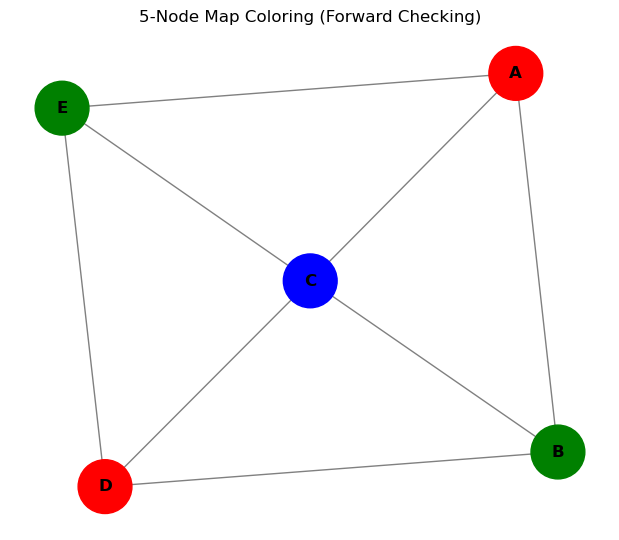

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import copy

class MapColoringCSP:
    def __init__(self, neighbors, colors):
        self.neighbors = neighbors
        self.colors = colors
        self.variables = list(neighbors.keys())
        self.domains = {v: list(colors) for v in self.variables}
        self.assignment = {}

    def solve(self):
        return self.backtrack(self.domains)

    def backtrack(self, domains):
        if len(self.assignment) == len(self.variables):
            return self.assignment

        # Select first unassigned variable
        var = [v for v in self.variables if v not in self.assignment][0]

        for value in domains[var]:
            if self.is_consistent(var, value):
                self.assignment[var] = value
                
                # --- FORWARD CHECKING ---
                new_domains = copy.deepcopy(domains)
                if self.forward_check(var, value, new_domains):
                    result = self.backtrack(new_domains)
                    if result:
                        return result
                
                del self.assignment[var] # Backtrack
        return None

    def is_consistent(self, var, value):
        for neighbor in self.neighbors[var]:
            if neighbor in self.assignment and self.assignment[neighbor] == value:
                return False
        return True

    def forward_check(self, var, value, domains):
        """Removes the assigned color from neighbors' potential domains."""
        for neighbor in self.neighbors[var]:
            if neighbor not in self.assignment:
                if value in domains[neighbor]:
                    domains[neighbor].remove(value)
                if not domains[neighbor]: # Domain Empty Failure
                    return False
        return True

# --- 5 NODE SETUP ---
# Region: [List of Neighbors]
map_nodes = {
    'A': ['B', 'C', 'E'],
    'B': ['A', 'C', 'D'],
    'C': ['A', 'B', 'D', 'E'],
    'D': ['B', 'C', 'E'],
    'E': ['A', 'C', 'D']
}
available_colors = ['red', 'green', 'blue']

# Solve
csp = MapColoringCSP(map_nodes, available_colors)
solution = csp.solve()

# --- VISUALIZATION ---
def visualize(neighbors, solution):
    G = nx.Graph()
    for node, edges in neighbors.items():
        for edge in edges:
            G.add_edge(node, edge)
    
    node_colors = [solution[node] for node in G.nodes()]
    
    plt.figure(figsize=(6, 5))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color=node_colors, 
            node_size=1500, font_weight='bold', edge_color='gray')
    plt.title("5-Node Map Coloring (Forward Checking)")
    plt.show()

if solution:
    print("Solution found:", solution)
    visualize(map_nodes, solution)
else:
    print("No solution found with 3 colors.")
